In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import simpest.models.simplace as simplace
import simpest.models.franchestyn as franchestyn

In [3]:
def plot_weather(df, columns, titles, colors=None, filter_dict=None):
    """
    Plots weather data with minimal configuration.
    
    Parameters:
    - df: DataFrame
    - columns: List of column names or lists of column names [['Tmin', 'Tmax'], 'Irradiation', ...]
    - titles: List of strings for subplot titles
    - colors: List of colors for each plot (optional)
    - filter_dict: Dict mapping column names to a filter condition string (optional)
                   e.g., {'Precipitation': '> 0'}
    """
    sns.set_theme()
    num_plots = len(columns)
    num_rows = math.ceil(num_plots / 2)
    
    fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        ax = axes[i]
        color = colors[i] if colors and i < len(colors) else None
        
        # 1. Handle Filtering if applicable
        plot_df = df
        if filter_dict:
            # Check if current col (or first element if it's a list) has a filter
            lookup_col = col[0] if isinstance(col, list) else col
            if lookup_col in filter_dict:
                plot_df = df.query(f"{lookup_col} {filter_dict[lookup_col]}")
        
        # 2. Plotting Logic
        if isinstance(col, list):
            # If a list of columns is given, melt and do a KDE plot
            melted = plot_df.melt(value_vars=col, var_name='Variable', value_name='Value')
            sns.kdeplot(data=melted, x='Value', hue='Variable', fill=True, ax=ax)
        else:
            # Otherwise, default to a histogram
            # (If it's ThermalRange, we can make it a KDE by checking its name, or leave it as hist)
            if col == 'ThermalRange':
                sns.kdeplot(data=plot_df, x=col, fill=True, color=color, ax=ax)
            else:
                sns.histplot(data=plot_df, x=col, kde=True, color=color, ax=ax)
                
        ax.set_title(titles[i])
        ax.set_xlabel('') # Cleans up automatically generated labels
        
    # Hide unused subplots
    for j in range(num_plots, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()


def read_df(path, sep=','):
    """
    Reads a CSV file into a DataFrame and ensures the 'date' column is in datetime format.
    
    Parameters:
    path (str): The path to the CSV file.
    sep (str): The delimiter to use. Default is ','.

    Returns:
    pd.DataFrame: The loaded DataFrame with 'date' column as datetime.
    """
    df = pd.read_csv(path, sep=sep)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    return df


## 2. Configuration

Define the input paths and run parameters. The `FRANCH_*` values configure the FraNchEstYN runner — crop, disease, and optional fungicide types, the site and variety, and the calibration settings.

In [4]:
SIMPLACE_INSTALL = 'C:/ParamVC/Research/simplace+/simplace_portable/workspace/'
SIMPLACE_WORK = f'{SIMPLACE_INSTALL}/simplace_run/simulation/'



path_weather = './data/weather_sim/indiana.txt'
path_weather_f = './data/weather_sim/weather_indiana_f.txt'
path_reference_f = './data/reference_fra/FRA_REFERENCE_Indiana.csv'
SOLUTION_PATH = './data/solution_sim/Lintul5_indiana.sol.xml'
PROJECT_PATH = './data/project_sim/Lintul5All_indiana.proj.xml'
SIMPLACE_OUT = './data/simpest_outputs/' 



# INPUTS
PROJECT_LINES = [1]

# FraNchEstYN Python runner config
FRANCH_CROP_TYPE = 'wheat'
FRANCH_DISEASE_TYPE = 'septoria'
FRANCH_FUNGICIDE_TYPE = None #'protectant'
FRANCH_SITE = 'indiana'
FRANCH_VARIETY = 'Generic'
FRANCH_DISEASE = 'thisDisease'
FRANCH_LATITUDE = 40.5
FRANCH_IS_CALIBRATION = True
FRANCH_CALIBRATION_VARIABLE = 'all'  # 'crop', 'disease', or 'all'
FRANCH_USE_GDD = False  # True: thermal-time (GDD) cycle percentage; False: calendar-day interpolation
FRANCH_USE_PREV_DAY_ALIGNMENT = True  # True: previous-day alignment (sim[d-1] vs ref[d]); False: same-day (sim[d] vs ref[d])
FRANCH_N_RESTARTS = 3
FRANCH_MAX_ITER = 10

In [5]:
sp_cfg = simplace.SimplaceConfig(install_dir=SIMPLACE_INSTALL, work_dir=SIMPLACE_WORK, output_dir=SIMPLACE_OUT,solution_path=SOLUTION_PATH, project_path=PROJECT_PATH,)


# Stage 1: Run SIMPLACE only
shell = simplace.init_simplace(sp_cfg)
simplace.run_simplace(shell, sp_cfg, project_lines=PROJECT_LINES)

dirs = simplace.get_simplace_directories(shell)
work_root = Path(dirs["_WORKDIR_"])
output_root = Path(dirs["_OUTPUTDIR_"])
selected_line = PROJECT_LINES[0]
project_row = simplace.get_project_row(work_root, selected_line=selected_line)
simplace_daily_path = output_root / "SimulationExperimentTemplate" / f"{project_row['location']}{project_row['iopt']}_daily.csv"
start_year = int(project_row["startdate"].split(".")[-1])
end_year = int(project_row["enddate"].split(".")[-1])
print('SIMPLACE completed')
print('SIMPLACE daily output:', simplace_daily_path)


SIMPLACE completed
SIMPLACE daily output: data\simpest_outputs\SimulationExperimentTemplate\indiana4_daily.csv


**SIMPLACE outputs visualisation**

Visualise the daily crop-model variables grouped by process (growth, biomass and yield, water fluxes, radiation, and so on).

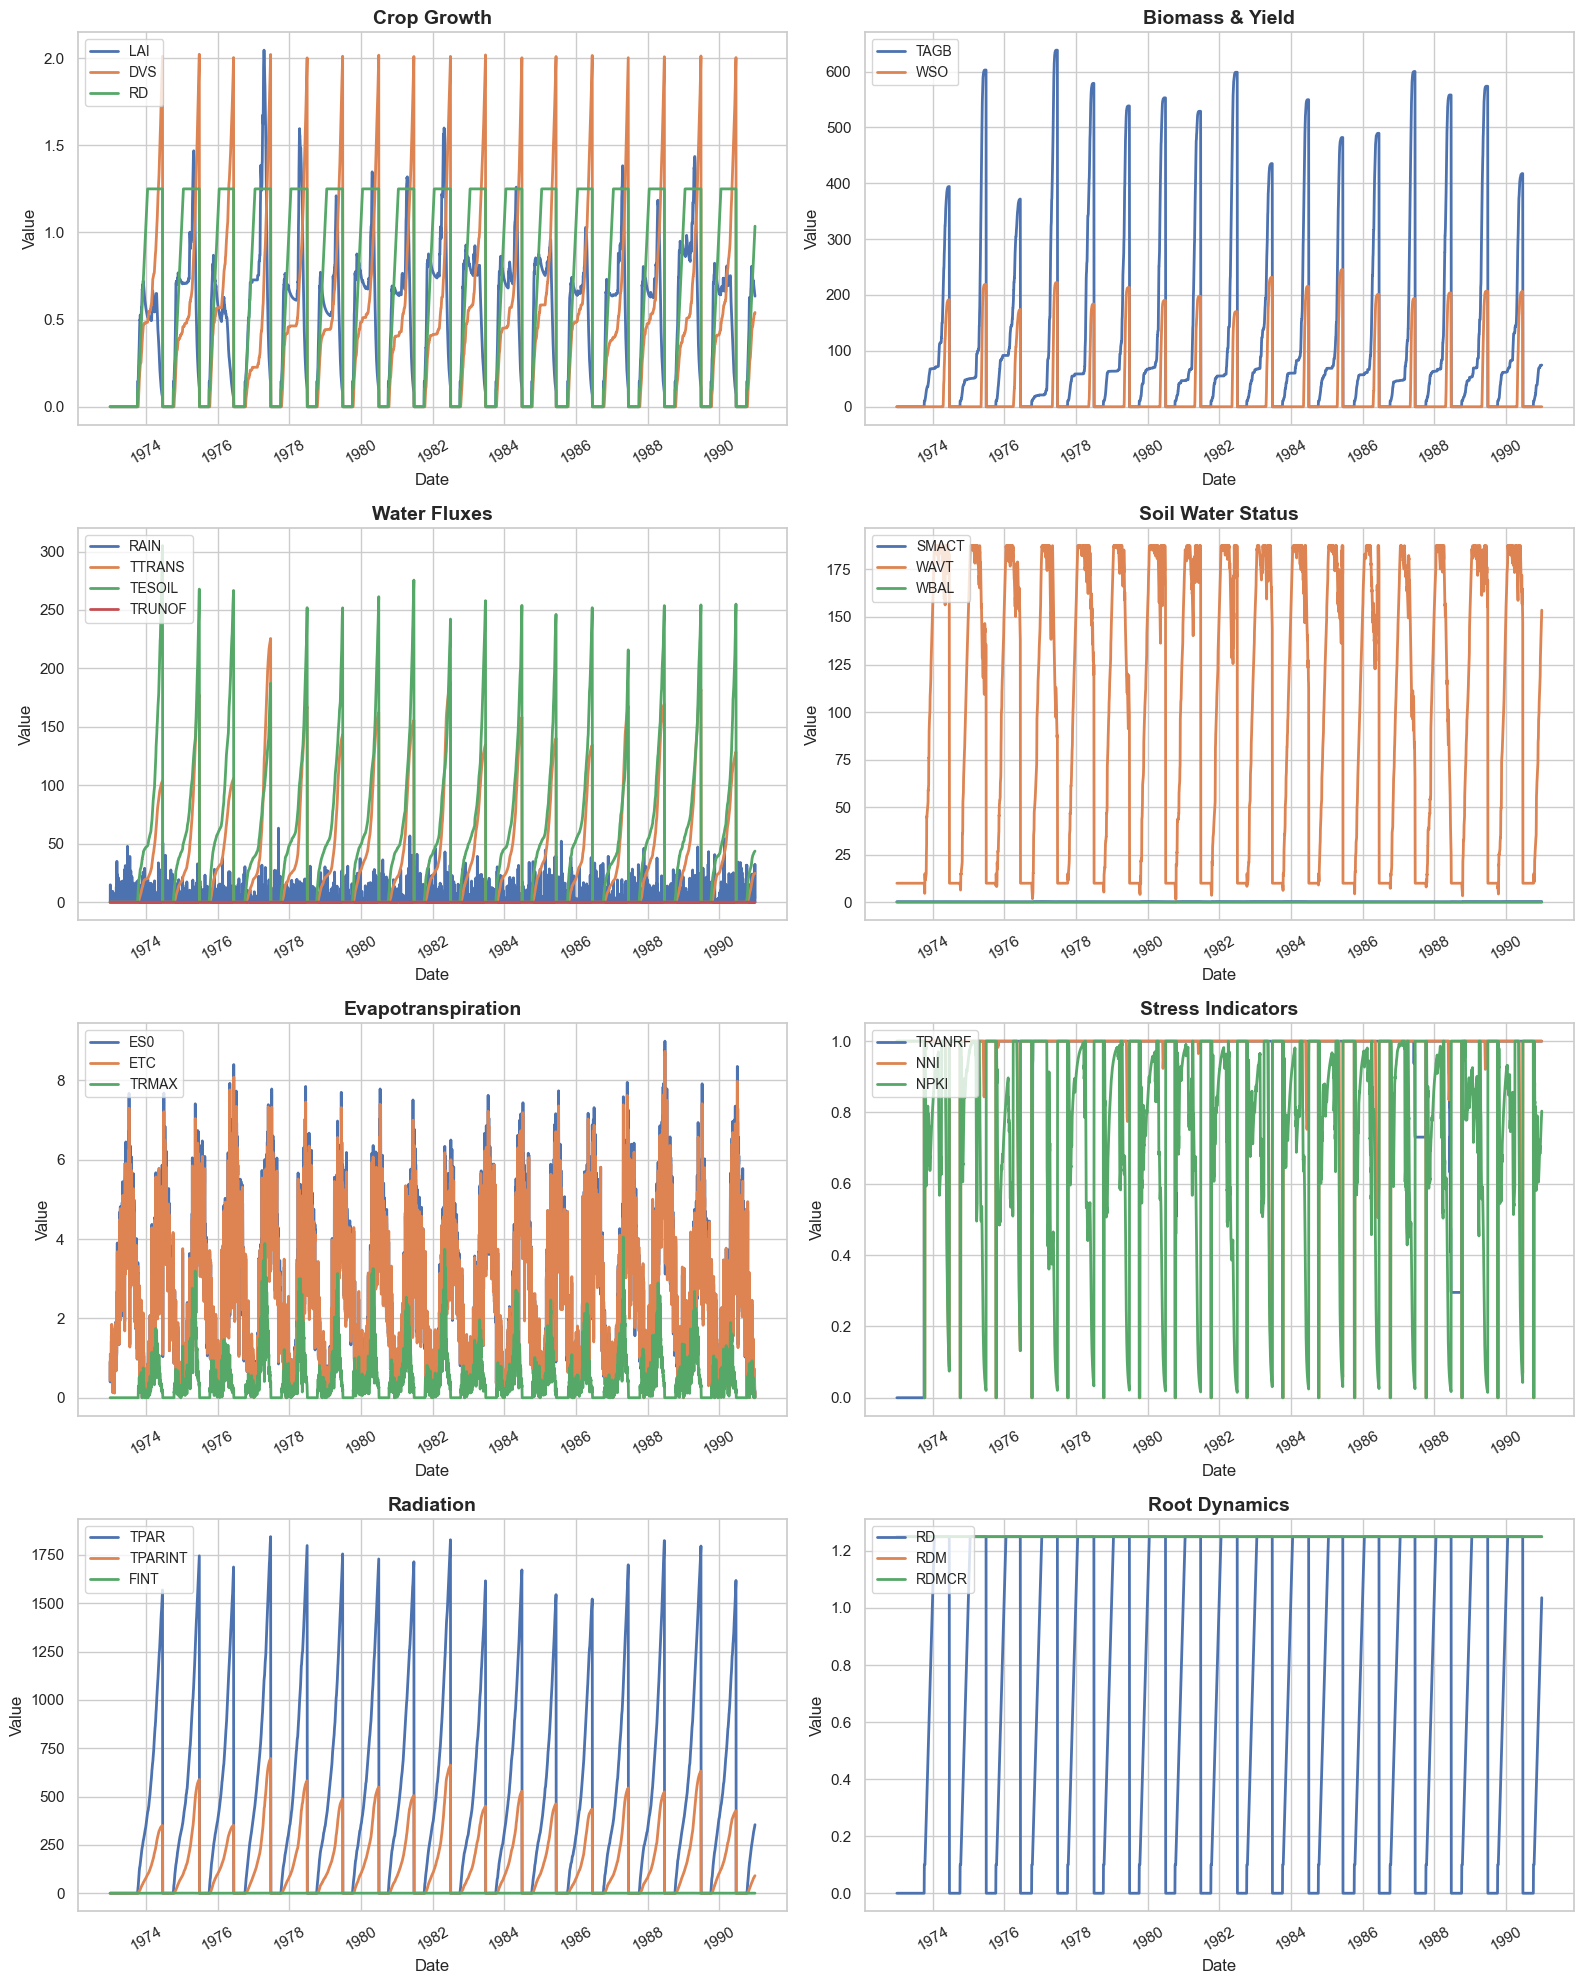

In [6]:
# Visualize SIMPLACE outputs (run after Stage 1)
sim_df = pd.read_csv(simplace_daily_path, sep=';')
sim_df['date'] = pd.to_datetime(sim_df['CURRENT.DATE'], format='%d.%m.%Y')
sim_df['TAGB'] = pd.to_numeric(sim_df['TAGB'], errors='coerce')
sim_df['WSO'] = pd.to_numeric(sim_df['WSO'], errors='coerce')

df = sim_df.copy()
df["date"] = pd.to_datetime(df["CURRENT.DATE"], dayfirst=True)

groups = [
    ("Crop Growth", ["LAI", "DVS", "RD"]),
    ("Biomass & Yield", ["TAGB", "WSO"]),
    ("Water Fluxes", ["RAIN", "TTRANS", "TESOIL", "TRUNOF"]),
    ("Soil Water Status", ["SMACT", "WAVT", "WBAL"]),
    ("Evapotranspiration", ["ES0", "ETC", "TRMAX"]),
    ("Stress Indicators", ["TRANRF", "NNI", "NPKI"]),
    ("Radiation", ["TPAR", "TPARINT", "FINT"]),
    ("Root Dynamics", ["RD", "RDM", "RDMCR"])
]

sns.set_theme(style="whitegrid")
n_groups = len(groups)
n_cols = 2
n_rows = (n_groups + 1) // n_cols  # Calculates rows needed for 2 columns

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()  # Flatten to easily iterate

for i, (title, variables) in enumerate(groups):
    ax = axes[i]
    
    # Plot each variable in the group
    for var in variables:
        if var in df.columns:
            sns.lineplot(data=df, x="date", y=var, ax=ax, label=var, linewidth=2)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend(loc='upper left', fontsize='small')
    
    # Rotate date labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=30)

# Remove any empty subplots if the number of groups is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**PEST Model simulation**

In [7]:
# crop_model_path = simplace.export_crop_model_data(output_root, project_row)
# weather_path = simplace.convert_weather(work_root, output_root, project_row["location"])
# management_path = simplace.build_management(output_root, project_row)

In [8]:
crop_model_path = "data/New/franchestyn_crop_model_data.csv" #simplace.export_crop_model_data(output_root, project_row)
weather_path =  "data/New/weather_indiana.csv" # simplace.convert_weather(work_root, output_root, project_row["location"])
management_path = "data/New/management_indiana.csv" # simplace.build_management(output_root, project_row)


crop_model_df = read_df(crop_model_path)
weather_df = read_df(weather_path)
management_df = read_df(management_path)
ref_df = read_df(path_reference_f)  # Assuming the reference file uses semicolon as delimiter


In [9]:
fr_cfg = franchestyn.FranchestynConfig(
    crop_type=FRANCH_CROP_TYPE,
    disease_type=FRANCH_DISEASE_TYPE,
    fungicide_type=FRANCH_FUNGICIDE_TYPE,
    site=FRANCH_SITE,
    variety=FRANCH_VARIETY,
    disease=FRANCH_DISEASE,
    is_calibration=FRANCH_IS_CALIBRATION,
    calibration_variable= 'disease', # FRANCH_CALIBRATION_VARIABLE,
    use_gdd=FRANCH_USE_GDD,
    use_prev_day_alignment=FRANCH_USE_PREV_DAY_ALIGNMENT,
    n_restarts=3,  # FRANCH_N_RESTARTS,
    max_iter=100,  # FRANCH_MAX_ITER,
)

# Parameter names to exclude from calibration
crop_disable = {"PartitioningMaximum", "TbaseCrop", "TmaxCrop", "ToptCrop", "FloweringStart", "RadiationUseEfficiency"}
disease_disable = {"RUEreducerDamage", "LightStealerDamage", "SenescenceAcceleratorDamage", "AssimilateSappersDamage"}

fr_cfg.crop_parameters = franchestyn.deactivate_calibration(fr_cfg.crop_parameters, crop_disable)
fr_cfg.disease_parameters = franchestyn.deactivate_calibration(fr_cfg.disease_parameters, disease_disable)

In [10]:
# Stage 2: Run FraNchEstYN using in-memory DataFrame inputs
result = franchestyn.run_franchestyn(
    weather_df=weather_df,
    management_df=management_df,
    crop_model_df=crop_model_df,
    ref_df=ref_df,
    start_year=1971,  
    end_year=1992,   
    config=fr_cfg,
)

summary = result['outputs']['summary']
simulation = result['outputs']['simulation']

franchestyn.save_simulation_results_csv(simulation, output_root)
simulation_df = pd.DataFrame(simulation)
season_summary = franchestyn.build_season_summary(simulation_df, site=fr_cfg.site, variety=fr_cfg.variety)
franchestyn.save_season_summary_csv(season_summary, output_root)

best_params = summary.get('best_params', {}) if isinstance(summary, dict) else {}
franchestyn.save_calibrated_parameters_csv(
    best_params,
    output_root,
    site=fr_cfg.site,
    variety=fr_cfg.variety,
    config=fr_cfg,
    r_like=True,
)
merged_path = simplace.merge_simplace_and_franchestyn(output_root, project_row, simulation_df)

print('FraNchEstYN completed')
print('Merged output:', merged_path)
print('RMSE:', summary.get('rmse'))

- Calibrating 16 using multi-start simplex method.
- Parameters:
['disease_OuterInoculumMax', 'disease_PathogenSpread', 'disease_WetnessDurationOptimum', 'disease_WetnessDurationMinimum', 'disease_DryCriticalInterruption', 'disease_Tmin', 'disease_Topt', 'disease_Tmax', 'disease_RelativeHumidityCritical', 'disease_Rain50Detachment', 'disease_RelativeHumidityNotLimiting', 'disease_HydroThermalTimeOnset', 'disease_CyclePercentageOnset', 'disease_LatencyDuration', 'disease_SporulationDuration', 'disease_OuterInoculumShapeParameter']
Run 3/3 Iteration 100/100 CURR RMSE=21.7750
Best RMSE: 20.3460
{'disease_OuterInoculumMax': np.float64(0.2251794314180426), 'disease_PathogenSpread': np.float64(0.09914501395006686), 'disease_WetnessDurationOptimum': np.float64(38.67574097758746), 'disease_WetnessDurationMinimum': np.float64(8.341645204598269), 'disease_DryCriticalInterruption': np.float64(21.019573754491315), 'disease_Tmin': np.float64(6.650702104477039), 'disease_Topt': np.float64(18.5101764